In [2]:
# ==== Core Libraries ====
import os
import random
from collections import Counter
from datetime import datetime

# ==== Data Processing ====
import numpy as np
import pandas as pd
from scipy import stats

# ==== PyTorch ====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast, GradScaler

# ==== Machine Learning Utils ====
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# ==== Visualization ====
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
class Discriminator(nn.Module):
    def __init__(self, input_channel, features_d, num_classes, num_aps, input_width):
        super(Discriminator, self).__init__()
        self.num_classes = num_classes
        self.num_aps = num_aps
        self.input_width = input_width
        self.input_channel = input_channel

        if self.num_aps == 11:
            last_kernal_size = 12
            last_stride = 5
            last_padding = 4

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(self.input_channel, features_d, kernel_size=4, stride=1, padding=4),
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 10, 1, 4),
            self._block(features_d * 2, features_d * 4, 10, 1, 4),
            self._block(features_d * 4, features_d * 8, 10, 2, 4),
        )

        self.classifier = nn.Conv2d(features_d * 8, num_classes + 1,
                                    kernel_size=last_kernal_size,
                                    stride=last_stride,
                                    padding=last_padding)

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x, labels,return_features=False):
        features = self.feature_extractor(x)  # shape: [B, F, H, W]
        logits = self.classifier(features)    # shape: [B, K+1, 1, 1]
        logits = logits.view(logits.size(0), -1)  # shape: [B, K+1]

        if return_features:
          return logits, features
        else:
          return logits


class Generator(nn.Module):
  def __init__(self,
                channels_noise,
                input_channel,
                features_g,
                num_classes,
                num_aps,
                input_width,
                embed_size):
    super(Generator, self).__init__()
    self.num_aps = num_aps
    self.input_channel = input_channel
    self.input_width = input_width
    self.embed_size = embed_size
    self.net = nn.Sequential(
      self._block(channels_noise + embed_size, features_g * 8, 10, 1, 4),
      self._block(features_g * 8, features_g * 4, 10, 1, 4),
      self._block(features_g * 4, features_g * 2, 10, 1, 4),
      self._block(features_g * 2, features_g, 10, 1, 4),
      nn.ConvTranspose2d(features_g, input_channel, kernel_size=9, stride=1, padding=6),
      nn.Tanh(),
    )
    self.embed = nn.Embedding(num_classes, embed_size * num_aps * input_width)


  def _block(self, in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
      nn.ConvTranspose2d(
          in_channels, out_channels, kernel_size, stride, padding, bias=False,
      ),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(),
    )

  def forward(self, x, labels):
    embedding = self.embed(labels).view(labels.shape[0], self.embed_size, self.num_aps, self.input_width)
    x = torch.cat([x, embedding], dim=1)
    return self.net(x)

In [4]:
def get_gradient_norm(model):
  total_norm = 0.0
  for p in model.parameters():
    if p.grad is not None:
      param_norm = p.grad.data.norm(2)
      total_norm += param_norm.item() ** 2
  return total_norm ** 0.5

def freeze_discriminator(disc, num_classes, unfreeze_net_last=False):

  # === Freeze everything by default ===
  #for param in disc.parameters():
    #param.requires_grad = False

  # === Reinitialize the classifier layer ===
  with torch.no_grad():
    old_classifier = disc.classifier
    disc.classifier = nn.Conv2d(
        in_channels=old_classifier.in_channels,
        out_channels=num_classes + 1,     # NUM_CLASSES + 1 fake
        kernel_size=old_classifier.kernel_size,
        stride=old_classifier.stride,
        padding=old_classifier.padding,
        bias=True
    )

  # === Unfreeze classifier ===
  for param in disc.classifier.parameters():
    param.requires_grad = True

def freeze_generator(gen):
  for param in gen.parameters():
      param.requires_grad = False

In [5]:
def load_pretrained_models(checkpoint_path, features_disc):
  checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

  gen = Generator(Z_DIM, CHANNELS_RSSI, FEATURES_GEN, NUM_CLASSES, APs, WINDOW_SIZE, GEN_EMBEDDING)
  disc = Discriminator(CHANNELS_RSSI, FEATURES_DISC, NUM_CLASSES, APs, WINDOW_SIZE)

  with torch.no_grad():
    old_classifier = disc.classifier
    disc.classifier = torch.nn.Conv2d(
        in_channels=old_classifier.in_channels,
        out_channels=NUM_CLASSES + 1,  # 10 rooms + 1 fake
        kernel_size=old_classifier.kernel_size,
        stride=old_classifier.stride,
        padding=old_classifier.padding,
        bias=True
    )

  gen_state_dict = checkpoint["gen_state_dict"]
  filtered_state_dict = {
    k: v for k, v in gen_state_dict.items()
    if k in gen.state_dict() and gen_state_dict[k].shape == gen.state_dict()[k].shape
    and not k.startswith("embed")
  }
  gen.load_state_dict(filtered_state_dict, strict=False)

  disc_state_dict = checkpoint["disc_state_dict"]
  filtered_disc_state_dict = {
    k: v for k, v in disc_state_dict.items()
    if k in disc.state_dict()
    and disc_state_dict[k].shape == disc.state_dict()[k].shape
    and not k.startswith("classifier")
  }
  disc.load_state_dict(filtered_disc_state_dict, strict=False)

  freeze_discriminator(disc, num_classes=NUM_CLASSES)
  freeze_generator(gen)

  gen = gen.to(DEVICE)
  disc = disc.to(DEVICE)

  # Optimizers and scalers
  opt_gen = torch.optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
  opt_disc = torch.optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
  scaler = GradScaler()

  scaler.load_state_dict(checkpoint['scaler_state_dict'])

  scheduler_gen = torch.optim.lr_scheduler.StepLR(opt_gen, step_size=30, gamma=0.5)
  scheduler_disc = torch.optim.lr_scheduler.StepLR(opt_disc, step_size=30, gamma=0.5)

  return gen, disc, opt_disc, scaler, scheduler_disc

In [6]:
def prepare_training_loaders(labeled_npz, unlabeled_npz):

  # Load labeled data
  data_labeled = np.load(labeled_npz)
  X_labeled = data_labeled["X"]  # shape [N, window_size, num_features]
  y_labeled = data_labeled["y"]  # shape [N]

  # Transpose X to [N, 1, num_features, window_size]
  X_labeled = np.transpose(X_labeled, (0, 2, 1))  # [N, 11, window_size]
  X_labeled = np.expand_dims(X_labeled, axis=1)   # [N, 1, 11, window_size]

  X_labeled_tensor = torch.tensor(X_labeled).float()
  y_labeled_tensor = torch.tensor(y_labeled).long()

  labeled_dataset = TensorDataset(X_labeled_tensor, y_labeled_tensor)
  loader_train = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

  # Load unlabeled data
  data_unlabeled = np.load(unlabeled_npz)
  X_unlabeled = data_unlabeled["X"]  # shape [N, window_size, num_features]

  # Transpose X to [N, 1, num_features, window_size]
  X_unlabeled = np.transpose(X_unlabeled, (0, 2, 1))
  X_unlabeled = np.expand_dims(X_unlabeled, axis=1)

  X_unlabeled_tensor = torch.tensor(X_unlabeled).float()

  unlabeled_dataset = TensorDataset(X_unlabeled_tensor)
  loader_unlabeled_train = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

  # Class balancing
  class_counts = np.bincount(y_labeled_tensor.numpy(), minlength=NUM_CLASSES)
  threshold = np.percentile(class_counts, 20)
  small_classes = torch.where(torch.tensor(class_counts) <= threshold)[0]
  small_classes = small_classes.tolist()

  weights_real_only = (1.0 / (class_counts + 1e-6)) ** 1.5
  weights_real_only = weights_real_only / weights_real_only.sum()

  # Extend with weight for fake class (class index NUM_CLASSES)
  weights_with_fake = np.append(weights_real_only, 1.0)  # Dummy value for fake class
  weights_real_only = torch.tensor(weights_real_only, dtype=torch.float32).to(DEVICE)
  weights_with_fake = torch.tensor(weights_with_fake, dtype=torch.float32).to(DEVICE)

  # Define losses
  criterion_real_full = nn.CrossEntropyLoss(weight=weights_with_fake)    # For D real
  criterion_real_10   = nn.CrossEntropyLoss(weight=weights_real_only)    # For G
  criterion_fake      = nn.CrossEntropyLoss()                            # For D

  return (
        loader_train,
        loader_unlabeled_train,
        criterion_real_full,
        criterion_real_10,
        criterion_fake,
        small_classes
    )

In [7]:
def prepare_validation_loader(unlabeled_eval_npz):

  # Load data
  data = np.load(unlabeled_eval_npz)
  X = data["X"]  # [N, window_size, num_features]
  y = data["y"]  # [N]

  # Transpose and format
  X = np.transpose(X, (0, 2, 1))  # [N, num_features, window_size]
  X = np.expand_dims(X, axis=1)   # [N, 1, num_features, window_size]

  X_tensor = torch.tensor(X).float()
  y_tensor = torch.tensor(y).long()

  val_dataset = TensorDataset(X_tensor, y_tensor)
  val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

  return val_loader

In [8]:
# Training loop
def train_k_plus_1_gan(gen, disc, opt_gen, opt_disc, scaler, scheduler_gen, scheduler_disc,
                       loader_train, loader_unlabeled_train,
                       criterion_real_full, criterion_real_10, criterion_fake,
                       split_ratio, experiment_name, save_csv_path, learning_rate, ramp_up_epochs, base_consistency_weight, grad_clip, temp_sharpen):

  training_logs = []

  for epoch in range(NUM_EPOCHS):
    gen.train()
    disc.train()

    consistency_weight = min(1.0, max(0, epoch) / ramp_up_epochs) * base_consistency_weight

    disc_total_loss = 0
    #gen_total_loss = 0
    num_batches = 0
    correct = 0
    total = 0
    avg_fake_conf_total = 0
    avg_real_class_conf_total = 0
    real_correct_total = 0
    fake_correct_total = 0

    unlabeled_iter = iter(loader_unlabeled_train)

    for batch_idx, (real_labeled, labels_labeled) in enumerate(loader_train):
      real_labeled = real_labeled.to(DEVICE)
      labels_labeled = labels_labeled.to(DEVICE).long()
      cur_batch_size = real_labeled.size(0)
      total += cur_batch_size

      # Sample unlabeled batch
      try:
        inputs_u, = next(unlabeled_iter)
      except StopIteration:
        unlabeled_iter = iter(loader_unlabeled_train)
        inputs_u, = next(unlabeled_iter)
      inputs_u = inputs_u.to(DEVICE)

      # Train Discriminator
      noise = torch.randn(cur_batch_size, Z_DIM, APs, WINDOW_SIZE).uniform_(-1, 1).to(DEVICE)

      with autocast("cuda"):
        fake = gen(noise, labels_labeled)

        # Forward passes
        real_logits, real_features = disc(real_labeled, labels_labeled, return_features=True)
        fake_logits, fake_features = disc(fake.detach(), labels_labeled, return_features=True)

        unlabeled_logits = disc(inputs_u, torch.zeros(inputs_u.size(0), dtype=torch.long).to(DEVICE))

        # Loss on labeled real
        real_loss = criterion_real_full(real_logits, labels_labeled)

        # Loss on fake (should predict FAKE class = NUM_CLASSES)
        fake_targets = torch.full_like(labels_labeled, NUM_CLASSES)
        fake_loss = criterion_fake(fake_logits, fake_targets)

        # Loss on unlabeled: encourage to predict real class (0-9), not fake (10)
        prob_unlabeled = torch.softmax(unlabeled_logits, dim=1)
        loss_unlabeled = -torch.mean(torch.log(1.0 - prob_unlabeled[:, NUM_CLASSES] + 1e-6))  # minimize fake probability

        # Total Discriminator Loss
        if consistency_weight > 0:

          # Forward pass on original and perturbed
          logits_u = disc(inputs_u, torch.zeros(inputs_u.size(0), dtype=torch.long).to(DEVICE))
          probs_u = torch.softmax(unlabeled_logits/ temp_sharpen, dim=1)
          log_probs_u = torch.log_softmax(logits_u/ temp_sharpen, dim=1)

          # === Confidence thresholding ===
          max_probs, pseudo_labels = probs_u[:, :NUM_CLASSES].max(dim=1)  # Only real classes
          # Dynamic threshold per class
          threshold_per_class = torch.full((NUM_CLASSES,), 0.9, device=DEVICE)
          for class_id in small_classes:
              threshold_per_class[class_id] = 0.7

          # Gather dynamic thresholds based on pseudo_labels
          dynamic_thresholds = threshold_per_class[pseudo_labels]

          # Create mask based on dynamic thresholds
          mask = (max_probs >= dynamic_thresholds).float()

          # === Compute masked consistency loss
          consistency_per_sample = torch.sum(-probs_u * log_probs_u, dim=1)
          consistency_loss = (mask * consistency_per_sample).mean()

        else:
          consistency_loss = 0.0

        # Total D loss
        total_disc_loss = real_loss + 0.1 * fake_loss + 1.0 * loss_unlabeled + consistency_weight * consistency_loss


      disc.zero_grad()
      scaler.scale(total_disc_loss).backward(retain_graph=True)
      scaler.unscale_(opt_disc)
      torch.nn.utils.clip_grad_norm_(disc.parameters(), max_norm=10.0)
      scaler.step(opt_disc)

      scaler.update()

      # === Stats ===
      with torch.no_grad():
        real_probs = torch.softmax(real_logits, dim=1)
        real_class_conf = real_probs.gather(1, labels_labeled.unsqueeze(1)).mean().item()
        avg_real_class_conf_total += real_class_conf

        fake_probs = torch.softmax(fake_logits, dim=1)
        avg_fake_conf = fake_probs[:, NUM_CLASSES].mean().item()
        avg_fake_conf_total += avg_fake_conf

        preds_real = real_logits.argmax(dim=1)
        real_correct = (preds_real == labels_labeled).sum().item()

        preds_fake = fake_logits.argmax(dim=1)
        fake_correct = (preds_fake == NUM_CLASSES).sum().item()

        real_correct_total += real_correct
        fake_correct_total += fake_correct
        correct += real_correct + fake_correct

      disc_total_loss += total_disc_loss.item()
      #gen_total_loss += loss_gen.item()
      num_batches += 1

    scheduler_disc.step()
    #scheduler_gen.step()

    #avg_gen_loss = gen_total_loss / num_batches
    avg_disc_loss = disc_total_loss / num_batches
    real_acc = real_correct_total / total
    fake_acc = fake_correct_total / total
    overall_acc = correct / total
    avg_fake_conf_epoch = avg_fake_conf_total / num_batches
    avg_real_class_conf_epoch = avg_real_class_conf_total / num_batches

    training_logs.append({
      "experiment": experiment_name,
      "split_ratio": split_ratio,
      "learning_rate": LEARNING_RATE,
      "features_disc": FEATURES_DISC,
      "epoch": epoch + 1,
      "disc_loss": avg_disc_loss,
      #"gen_loss": avg_gen_loss,
      "acc_real": real_acc,
      "acc_fake": fake_acc,
      "acc_overall": overall_acc,
      "avg_fake_conf": avg_fake_conf_epoch,
      "avg_real_class_conf": avg_real_class_conf_epoch
          })

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
      f"Loss D: {avg_disc_loss:.4f}, "
      #f"Loss G: {avg_gen_loss:.4f}, "
      f"Acc (real): {real_acc:.4f}, "
      f"Acc (fake): {fake_acc:.4f}, "
      f"Acc Overall: {overall_acc:.4f}, "
      f"Avg fake conf {avg_fake_conf_epoch:.4f}, "
      f"Avg real class conf: {avg_real_class_conf_epoch:.4f}, ")

    # if epoch == NUM_EPOCHS - 1:
    #     torch.save({
    #         'epoch': epoch,
    #         'gen_state_dict': gen.state_dict(),
    #         'disc_state_dict': disc.state_dict(),
    #         'opt_gen_state_dict': opt_gen.state_dict(),
    #         'opt_disc_state_dict': opt_disc.state_dict(),
    #         'scaler_state_dict': scaler.state_dict(),
    #         'scheduler_gen_state_dict': scheduler_gen.state_dict(),
    #         'scheduler_disc_state_dict': scheduler_disc.state_dict(),
    #     }, f"/content/drive/MyDrive/rssi_project/ssl_gan/{experiment_name}_final.pt")

  # Save the full log after training
  df_logs = pd.DataFrame(training_logs)
  df_logs.to_csv(save_csv_path, mode='a', index=False, header=not os.path.exists(save_csv_path))

In [9]:
def evaluate_supervised_gan(disc, unlabeled_npz, house_d_label_to_id, model_name):

  # --- Run discriminator on validation set ---
  loader_unlabeled_val = prepare_validation_loader(unlabeled_npz)

  disc.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for X_batch, y_batch in loader_unlabeled_val:
      X_batch = X_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      dummy_labels = torch.zeros(X_batch.size(0), dtype=torch.long).to(DEVICE)
      logits = disc(X_batch, dummy_labels)
      preds = logits[:, :NUM_CLASSES].argmax(dim=1)

      all_preds.append(preds.cpu().numpy())
      all_labels.append(y_batch.cpu().numpy())

  # Flatten arrays
  all_preds = np.concatenate(all_preds)
  all_labels = np.concatenate(all_labels)

  label_names = list(house_d_label_to_id.keys())

  # --- Metrics ---
  acc = accuracy_score(all_labels, all_preds)
  macro_f1 = f1_score(all_labels, all_preds, average='macro')
  print(f"Accuracy: {acc:.4f}")
  print(f"Macro F1 Score: {macro_f1:.4f}")

  print(classification_report(
      all_labels,
      all_preds,
      labels=list(range(NUM_CLASSES)),
      target_names=label_names,
      digits=4,
      zero_division=0
  ))

  # --- Confusion Matrix ---
  cm = confusion_matrix(all_labels, all_preds)

  sns.heatmap(cm, annot=True, fmt='d',
              xticklabels=label_names, yticklabels=label_names)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix for K+1 GAN")
  plt.tight_layout()
  plt.show()

  return acc, macro_f1

In [10]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint_path = "/content/drive/MyDrive/rssi_project/ssl_gan/ConGAN_wgp_house_ssl_training_final.pt"
save_training_logs_csv = "/content/drive/MyDrive/rssi_project/ssl_gan/training_logs_k_plus_1_houseD.csv"
save_results_csv = "/content/drive/MyDrive/rssi_project/ssl_gan/results_k_plus_1_houseD.csv"

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)

house_d_label_to_id = {
    "living_area_A": 0,
    "kitchen": 1,
    "living_area_B": 2,
    "hallway_upper": 3,
    "bedroom_1": 4,
    "bedroom_2": 5,
    "hallway_lower": 6,
    "stairs": 7,
    "bathroom_toilet": 8,
    "outside": 9
}
house_d_id_to_label = {v: k for k, v in house_d_label_to_id.items()}

labeled_experiments = [
    #("experiment2", "10%"),
    #("experiment3", "5%"),
    ("experiment4", "1%")
]

# Hyperparameters
#LEARNING_RATE = 5e-5
BATCH_SIZE = 64
WINDOW_SIZE = 5
HOP = 1
CHANNELS_RSSI = 1
GEN_EMBEDDING = 100
Z_DIM = 11
#FEATURES_DISC = 128
FEATURES_GEN = 32
NUM_CLASSES = 10
APs = 11
NUM_EPOCHS = 200

FM_LOSS_WEIGHT = 0.5
GRAD_CLIP_OPTIONS = [True]
FEATURES_DISC_OPTIONS = [128]
LEARNING_RATE_OPTIONS = [5e-5]
RAMP_UP_EPOCHS_OPTIONS = [10]
BASE_CONSISTENCY_WEIGHT_OPTIONS = [0.5]
TEMP_SHARPEN_OPTIONS = [0.5]


🏡 Starting experiment4

➡️ FEATURES_DISC=128, LEARNING_RATE=5e-05, rampup=10, cons_weight=0.5, grad_clip=True, TEMP_SHARPEN=0.5
Epoch [1/200] Loss D: 4.6535, Acc (real): 0.0000, Acc (fake): 0.1795, Acc Overall: 0.1795, Avg fake conf 0.5348, Avg real class conf: 0.0441, 
Epoch [2/200] Loss D: 2.3870, Acc (real): 0.1026, Acc (fake): 1.0000, Acc Overall: 1.1026, Avg fake conf 0.9983, Avg real class conf: 0.1106, 
Epoch [3/200] Loss D: 1.8077, Acc (real): 0.5128, Acc (fake): 1.0000, Acc Overall: 1.5128, Avg fake conf 0.9983, Avg real class conf: 0.2136, 
Epoch [4/200] Loss D: 0.8921, Acc (real): 0.4744, Acc (fake): 1.0000, Acc Overall: 1.4744, Avg fake conf 0.9954, Avg real class conf: 0.3984, 
Epoch [5/200] Loss D: 1.0105, Acc (real): 0.4744, Acc (fake): 1.0000, Acc Overall: 1.4744, Avg fake conf 0.9790, Avg real class conf: 0.4620, 
Epoch [6/200] Loss D: 0.6828, Acc (real): 0.7436, Acc (fake): 1.0000, Acc Overall: 1.7436, Avg fake conf 0.9993, Avg real class conf: 0.6482, 
Epoch [7/200]

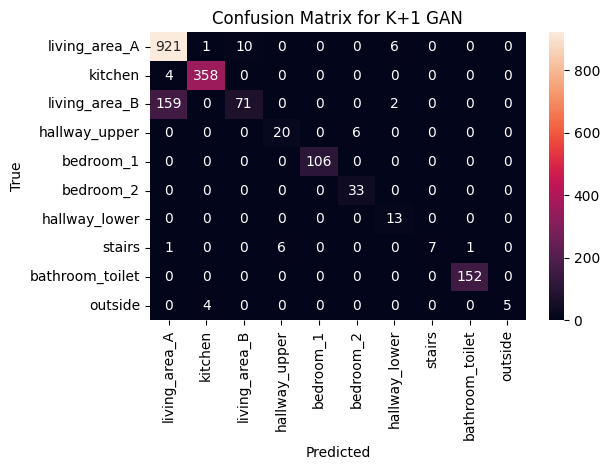


🎯 All K+1 GAN experiments completed and results saved!


In [11]:
all_results = []

for exp_name, split_ratio in labeled_experiments:

  labeled_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_labeled_{exp_name}.npz"
  unlabeled_train_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_unlabeled_{exp_name}_train.npz"
  unlabeled_eval_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_full_validation_set.npz"

  # Prepare training loaders
  (
    loader_train,
    loader_unlabeled_train,
    criterion_real_full,
    criterion_real_10,
    criterion_fake,
    small_classes
  ) = prepare_training_loaders(labeled_npz, unlabeled_train_npz)

  val_loader = prepare_validation_loader(unlabeled_eval_npz)

  for FEATURES_DISC in FEATURES_DISC_OPTIONS:
    for LEARNING_RATE in LEARNING_RATE_OPTIONS:
      for RAMP_UP_EPOCHS in RAMP_UP_EPOCHS_OPTIONS:
        for BASE_CONSISTENCY_WEIGHT in BASE_CONSISTENCY_WEIGHT_OPTIONS:
          for GRAD_CLIP in GRAD_CLIP_OPTIONS:
            for TEMP_SHARPEN in TEMP_SHARPEN_OPTIONS:

              print(f"➡️ FEATURES_DISC={FEATURES_DISC}, LEARNING_RATE={LEARNING_RATE}, rampup={RAMP_UP_EPOCHS}, cons_weight={BASE_CONSISTENCY_WEIGHT}, grad_clip={GRAD_CLIP}, TEMP_SHARPEN={TEMP_SHARPEN}")

              model_name = f"KPlus1GAN_{exp_name}_FDISC{FEATURES_DISC}_LR{LEARNING_RATE}_RAMP{RAMP_UP_EPOCHS}_CW{BASE_CONSISTENCY_WEIGHT}_CLIP{GRAD_CLIP}_TEMP_SHARPEN{TEMP_SHARPEN}"

              # Load models
              gen, disc, opt_disc, scaler, scheduler_disc = load_pretrained_models(checkpoint_path, FEATURES_DISC)

              # Optimizer for generator
              opt_gen = torch.optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
              scheduler_gen = torch.optim.lr_scheduler.StepLR(opt_gen, step_size=30, gamma=0.5)

              # Train the model
              train_k_plus_1_gan(
                gen, disc,
                opt_gen, opt_disc,
                scaler,
                scheduler_gen, scheduler_disc,
                loader_train, loader_unlabeled_train,
                criterion_real_full, criterion_real_10, criterion_fake,
                split_ratio,
                model_name,
                save_training_logs_csv,
                learning_rate=LEARNING_RATE,
                ramp_up_epochs=RAMP_UP_EPOCHS,
                base_consistency_weight=BASE_CONSISTENCY_WEIGHT,
                grad_clip=GRAD_CLIP,
                temp_sharpen=TEMP_SHARPEN
              )

              # Evaluate the model
              acc, macro_f1 = evaluate_supervised_gan(
                disc,
                unlabeled_eval_npz,
                house_d_label_to_id,
                model_name
              )

              # Log results
              all_results.append({
                  "experiment": exp_name,
                  "split_ratio": split_ratio,
                  "features_disc": FEATURES_DISC,
                  "learning_rate": LEARNING_RATE,
                  "ramp_up_epochs": RAMP_UP_EPOCHS,
                  "base_consistency_weight": BASE_CONSISTENCY_WEIGHT,
                  "grad_clip": GRAD_CLIP,
                  "temp_sharpen": TEMP_SHARPEN,
                  "accuracy": acc,
                  "macro_f1": macro_f1
              })

# Save all results
results_df = pd.DataFrame(all_results)
results_df.to_csv(save_results_csv, index=False)
print("\n🎯 All K+1 GAN experiments completed and results saved!")
